# Subject-Generalising DeFOG LSTM Episode Detector

## Goal

Predict whether FoG is occurring at the final timestamp of each genuine
chronological window. Subject splitting occurs first, windows cannot
cross recordings or missing-time gaps, and validation/test inference
uses stride one for precise episode timing.

## Setup

In [ ]:
from pathlib import Path
import sys
import gc
import importlib
import numpy as np

print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "This notebook requires NumPy 1.26.x. Select the "
        "'Dissertation FoG (.venv)' kernel and restart the notebook."
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "fog_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

importlib.invalidate_caches()
import fog_pipeline as _fog_pipeline
_fog_pipeline = importlib.reload(_fog_pipeline)

from fog_pipeline import (
    ANY_FOG_COLUMN,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    align_binary_predictions,
    assert_subject_disjoint,
    evaluate_episode_predictions,
    load_recordings,
    prepare_sequence_splits,
    select_episode_threshold,
    split_by_subject,
    split_summary,
)

RANDOM_STATE = 42
TIMESTEPS = 5
STRIDE = 5
EVALUATION_STRIDE = 1
FEATURE_WINDOW_SIZE = 5
EDA_SAMPLE_SIZE = 200_000
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 20
BATCH_SIZE = 4096
RUN_TRAINING = True
SAMPLING_RATE_HZ = 100.0
EPISODE_IOU_THRESHOLD = 0.25
MERGE_GAP_SECONDS = 0.0
MIN_PREDICTED_EPISODE_SECONDS = 0.0
MAX_RECORDINGS = None
REQUIRE_ALL_TARGETS = MAX_RECORDINGS is None

sns.set_theme(style="whitegrid", context="notebook")

Python executable: d:\Dissertation\.venv\Scripts\python.exe
NumPy version: 1.26.4


## Data — split complete subjects before making windows

In [2]:
raw_data = load_recordings(
    recordings_dir=PROJECT_ROOT / "data" / "raw" / "train" / "defog",
    metadata_path=PROJECT_ROOT / "data" / "metadata" / "defog_metadata.csv",
    limit_recordings=MAX_RECORDINGS,
    filter_valid_task=True,
)
SAMPLING_RATE_HZ = 100.0
raw_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,AnyFoG,RecordingId,Subject
0,1000,-0.970018,0.061626,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
1,1001,-0.984375,0.044497,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
2,1002,-0.984375,0.029016,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
3,1003,-0.984375,0.015625,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
4,1004,-0.984670,0.015330,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35


### Dataset overview and class balance

,dataset_overview
rows,4090530
recordings,91
subjects_or_file_groups,38
time_min,1000
time_max,414387


,missing_values
Time,0
AccV,0
AccML,0
AccAP,0
AnyFoG,0
StartHesitation,0
Turn,0
Walking,0
RecordingId,0
Subject,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
Time,4090530.0,91125.361824,70259.157136,1000.000000,1449.000000,35529.000000,76822.000000,129562.000000,325532.710000,414387.000000
AccV,4090530.0,-0.934946,0.107224,-6.024701,-1.265625,-0.985271,-0.939239,-0.886963,-0.664778,4.458364
AccML,4090530.0,-0.001229,0.140118,-2.115008,-0.357178,-0.084661,0.000000,0.092481,0.323602,4.524038
AccAP,4090530.0,-0.225780,0.244468,-5.118650,-0.750000,-0.363481,-0.250000,-0.113236,0.525120,4.388132
AnyFoG,4090530.0,0.167667,0.373570,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
StartHesitation,4090530.0,0.000122,0.011055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Turn,4090530.0,0.143460,0.350542,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
Walking,4090530.0,0.024084,0.153311,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


,rows_per_recording
count,91.000000
mean,44950.879121
std,24171.785040
min,8872.000000
25%,29555.500000
50%,39442.000000
75%,51773.000000
max,142610.000000


,positive_rows,prevalence_percent
AnyFoG,685847,16.766703
StartHesitation,500,0.012223
Turn,586829,14.346038
Walking,98518,2.408441


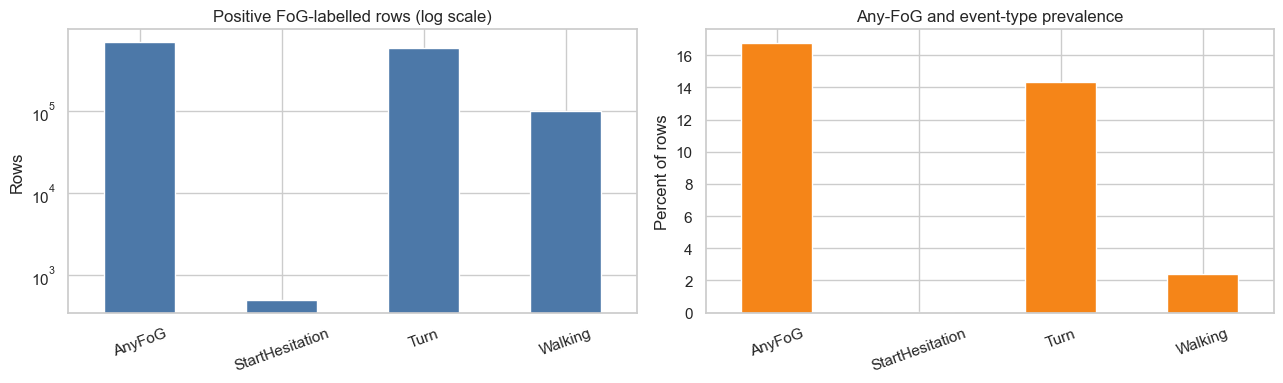

In [3]:
overview = pd.Series(
    {
        "rows": len(raw_data),
        "recordings": raw_data["RecordingId"].nunique(),
        "subjects_or_file_groups": raw_data["Subject"].nunique(),
        "time_min": raw_data["Time"].min(),
        "time_max": raw_data["Time"].max(),
    },
    name="dataset_overview",
)
display(overview.to_frame())

missing_summary = raw_data[
    [
        "Time",
        *FEATURE_COLUMNS[:3],
        ANY_FOG_COLUMN,
        *TARGET_COLUMNS,
        "RecordingId",
        "Subject",
    ]
].isna().sum().rename("missing_values")
display(missing_summary.to_frame())

numeric_summary = raw_data[
    ["Time", *FEATURE_COLUMNS[:3], ANY_FOG_COLUMN, *TARGET_COLUMNS]
].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
display(numeric_summary)

recording_lengths = raw_data.groupby("RecordingId", observed=True).size()
display(
    recording_lengths.describe().rename("rows_per_recording").to_frame()
)

event_columns = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
event_summary = pd.DataFrame(
    {
        "positive_rows": raw_data.loc[:, event_columns].sum(),
        "prevalence_percent": raw_data.loc[:, event_columns].mean() * 100,
    }
)
display(event_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
event_summary["positive_rows"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_yscale("log")
axes[0].set_title("Positive FoG-labelled rows (log scale)")
axes[0].set_ylabel("Rows")
event_summary["prevalence_percent"].plot.bar(ax=axes[1], color="#f58518")
axes[1].set_title("Any-FoG and event-type prevalence")
axes[1].set_ylabel("Percent of rows")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Representative sensor and event window

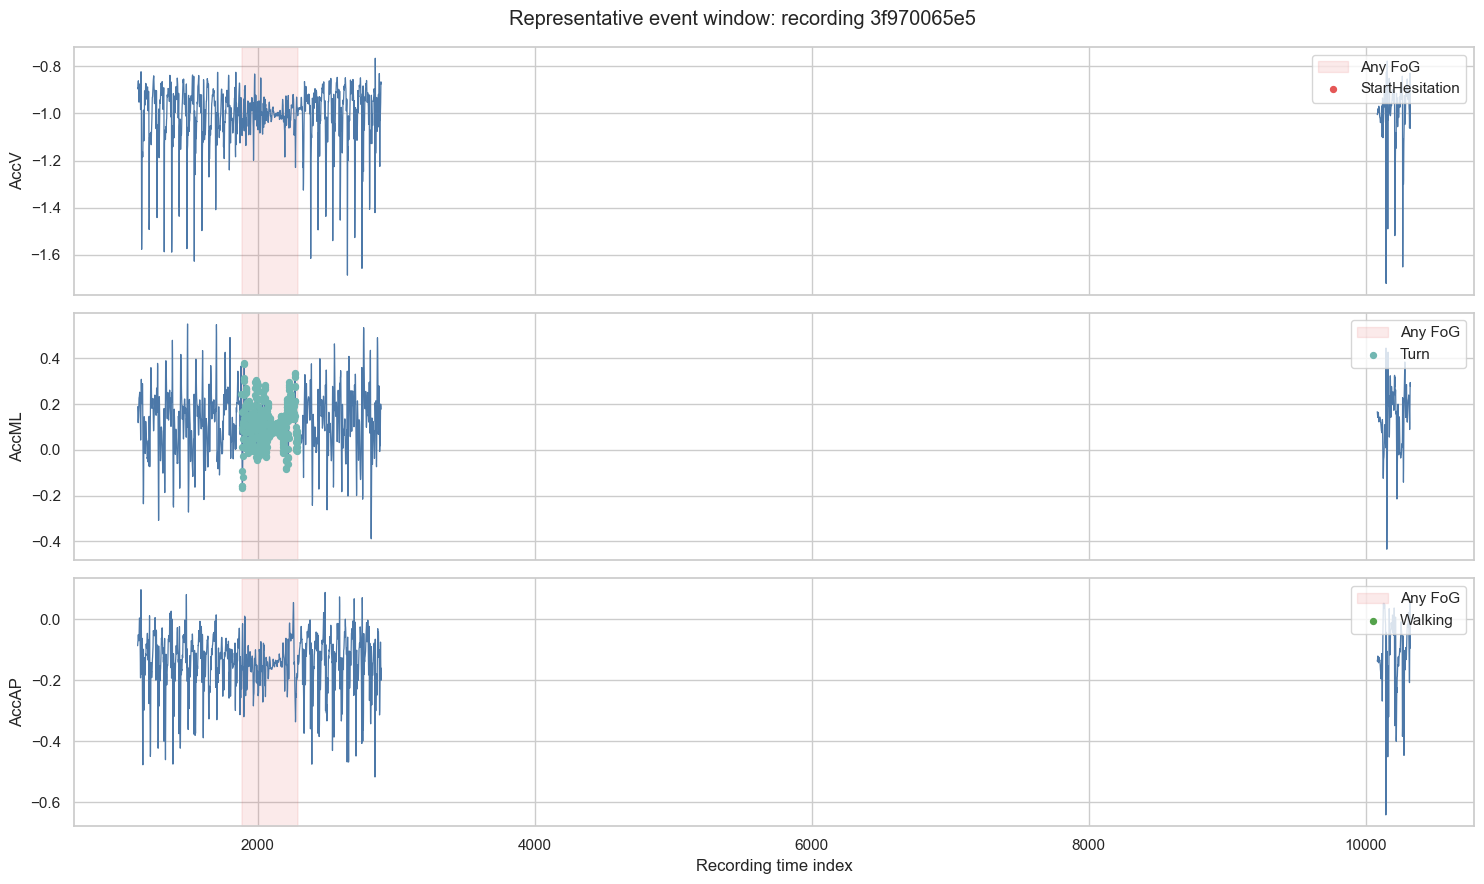

In [4]:
recording_event_totals = raw_data.groupby(
    "RecordingId", observed=True
)[list(TARGET_COLUMNS)].sum()
sample_recording_id = recording_event_totals.sum(axis=1).idxmax()
sample_recording = raw_data.loc[
    raw_data["RecordingId"] == sample_recording_id
].sort_values("Time", kind="stable")

event_positions = np.flatnonzero(
    sample_recording.loc[:, TARGET_COLUMNS].any(axis=1).to_numpy()
)
centre = int(event_positions[0]) if len(event_positions) else len(sample_recording) // 2
window_start = max(0, centre - 750)
window_end = min(len(sample_recording), centre + 1250)
plot_window = sample_recording.iloc[window_start:window_end]

sensor_event_pairs = [
    ("AccV", "StartHesitation", "#e45756"),
    ("AccML", "Turn", "#72b7b2"),
    ("AccAP", "Walking", "#54a24b"),
]
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for axis, (sensor, target, colour) in zip(axes, sensor_event_pairs):
    sensor_values = plot_window[sensor].copy()
    positive_time_steps = plot_window["Time"].diff().dropna()
    positive_time_steps = positive_time_steps.loc[positive_time_steps > 0]
    typical_step = float(positive_time_steps.median()) if len(positive_time_steps) else 1.0
    sensor_values.loc[plot_window["Time"].diff() > 5 * typical_step] = np.nan
    axis.plot(plot_window["Time"], sensor_values, linewidth=0.9, color="#4c78a8")
    axis.fill_between(
        plot_window["Time"],
        0,
        1,
        where=plot_window[ANY_FOG_COLUMN].astype(bool),
        transform=axis.get_xaxis_transform(),
        step="post",
        color="#e45756",
        alpha=0.12,
        label="Any FoG",
    )
    events = plot_window.loc[plot_window[target] == 1]
    axis.scatter(events["Time"], events[sensor], s=18, color=colour, label=target, zorder=3)
    axis.set_ylabel(sensor)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Recording time index")
fig.suptitle(f"Representative event window: recording {sample_recording_id}")
plt.tight_layout()
plt.show()

## Methods — subject-disjoint sequence splits

In [5]:
subject_splits = split_by_subject(
    raw_data,
    test_size=0.20,
    validation_size=0.20,
    random_state=RANDOM_STATE,
    require_all_targets=REQUIRE_ALL_TARGETS,
)
assert_subject_disjoint(subject_splits)
assert set(TARGET_COLUMNS).isdisjoint(FEATURE_COLUMNS)
assert ANY_FOG_COLUMN not in FEATURE_COLUMNS
print("Selected split seed:", subject_splits.random_state)
split_summary(subject_splits)

Selected split seed: 46


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,22,52,2458834,0.000092,0.147557,0.034482,0.182130
validation,8,21,792841,0.000114,0.102109,0.012824,0.115046
test,8,18,838855,0.000221,0.170537,0.004251,0.175009


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,22,52,2458834,0.000092,0.147557,0.034482,0.182130
validation,8,21,792841,0.000114,0.102109,0.012824,0.115046
test,8,18,838855,0.000221,0.170537,0.004251,0.175009


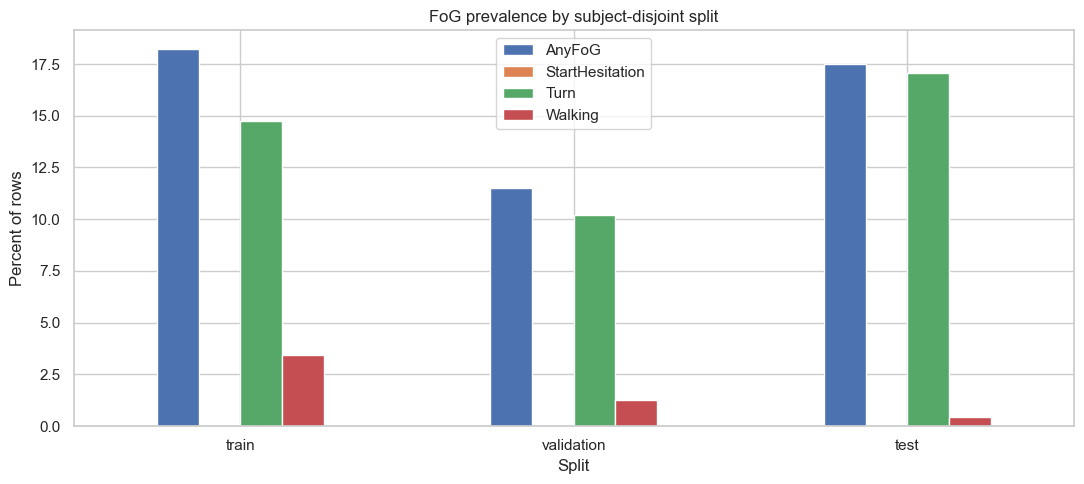

In [6]:
split_table = split_summary(subject_splits)
display(split_table)

rate_targets = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
rate_columns = [f"{target}_rate" for target in rate_targets]
rate_plot = split_table.loc[:, rate_columns].rename(
    columns={f"{target}_rate": target for target in rate_targets}
) * 100
rate_plot.plot.bar(figsize=(11, 5))
plt.title("FoG prevalence by subject-disjoint split")
plt.ylabel("Percent of rows")
plt.xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Sequences — preserve time and recording boundaries

,split,sequences,timesteps,prediction_stride,features
0,train,491338,5,5,10
1,validation,791337,5,1,10
2,test,837551,5,1,10


,train,validation,test
target,,,
AnyFoG,18.226761,11.523914,17.523232
StartHesitation,0.008955,0.011373,0.022088
Turn,14.768449,10.227754,17.075378
Walking,3.449357,1.284788,0.425765


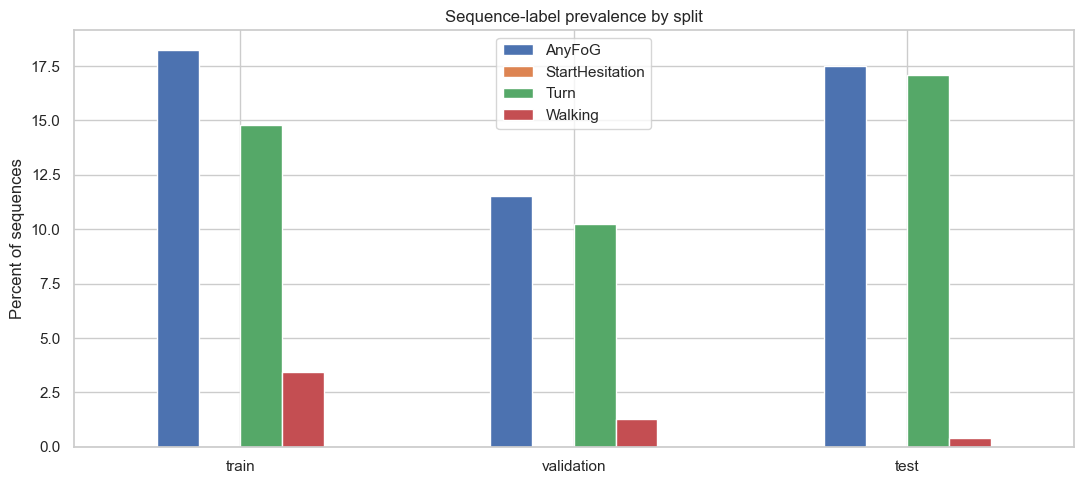

In [7]:
del raw_data
gc.collect()
prepared = prepare_sequence_splits(
    subject_splits,
    timesteps=TIMESTEPS,
    stride=STRIDE,
    evaluation_stride=EVALUATION_STRIDE,
    feature_window_size=FEATURE_WINDOW_SIZE,
)
del subject_splits
gc.collect()

sequence_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "sequences": [
            len(prepared.X_train),
            len(prepared.X_validation),
            len(prepared.X_test),
        ],
        "timesteps": TIMESTEPS,
        "prediction_stride": [
            STRIDE,
            EVALUATION_STRIDE,
            EVALUATION_STRIDE,
        ],
        "features": len(FEATURE_COLUMNS),
    }
)
display(sequence_summary)

sequence_event_rates = pd.DataFrame(
    {
        "train": np.concatenate(
            [prepared.y_any_fog_train, prepared.y_train], axis=1
        ).mean(axis=0),
        "validation": np.concatenate(
            [prepared.y_any_fog_validation, prepared.y_validation], axis=1
        ).mean(axis=0),
        "test": np.concatenate(
            [prepared.y_any_fog_test, prepared.y_test], axis=1
        ).mean(axis=0),
    },
    index=[ANY_FOG_COLUMN, *TARGET_COLUMNS],
) * 100
display(sequence_event_rates.rename_axis("target"))
sequence_event_rates.T.plot.bar(figsize=(11, 5))
plt.title("Sequence-label prevalence by split")
plt.ylabel("Percent of sequences")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Model — tune only with validation subjects

In [ ]:
model = None
history = None

if RUN_TRAINING:
    import tensorflow as tf

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    fog_train = prepared.y_any_fog_train
    fog_validation = prepared.y_any_fog_validation
    fog_negatives = float((1.0 - fog_train).sum())
    fog_positives = float(fog_train.sum())
    fog_positive_weight = float(
        np.clip(
            fog_negatives / max(fog_positives, 1.0), 1.0, 200.0
        )
    )
    type_negatives = (1.0 - prepared.y_train).sum(axis=0)
    type_positives = prepared.y_train.sum(axis=0)
    type_positive_weights = np.clip(
        type_negatives / np.maximum(type_positives, 1.0),
        1.0,
        200.0,
    )
    print(
        f"Any-FoG positive-class loss weight: {fog_positive_weight:.2f}"
    )
    print(
        "Auxiliary event-type weights:",
        dict(zip(TARGET_COLUMNS, type_positive_weights.round(2))),
    )

    def make_weighted_binary_crossentropy(positive_weights):
        weights = tf.constant(positive_weights, dtype=tf.float32)

        def weighted_binary_crossentropy(y_true, y_pred):
            y_pred = tf.clip_by_value(
                y_pred,
                tf.keras.backend.epsilon(),
                1.0 - tf.keras.backend.epsilon(),
            )
            loss = -(
                weights * y_true * tf.math.log(y_pred)
                + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
            )
            return tf.reduce_mean(loss)

        return weighted_binary_crossentropy

    inputs = tf.keras.layers.Input(
        shape=(TIMESTEPS, len(FEATURE_COLUMNS)),
        name="sensor_sequence",
    )
    shared = tf.keras.layers.LSTM(64, activation="tanh")(inputs)
    shared = tf.keras.layers.Dense(64, activation="relu")(shared)
    fog_output = tf.keras.layers.Dense(
        1, activation="sigmoid", name="fog"
    )(shared)
    event_type_output = tf.keras.layers.Dense(
        len(TARGET_COLUMNS),
        activation="sigmoid",
        name="event_type",
    )(shared)
    model = tf.keras.Model(
        inputs=inputs,
        outputs={"fog": fog_output, "event_type": event_type_output},
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            "fog": make_weighted_binary_crossentropy(
                fog_positive_weight
            ),
            "event_type": make_weighted_binary_crossentropy(
                type_positive_weights
            ),
        },
        loss_weights={"fog": 1.0, "event_type": 0.2},
        metrics={
            "fog": [
                tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.BinaryAccuracy(
                    name="binary_accuracy"
                ),
            ],
            "event_type": [
                tf.keras.metrics.AUC(
                    curve="PR",
                    multi_label=True,
                    num_labels=len(TARGET_COLUMNS),
                    name="pr_auc",
                )
            ],
        },
    )
    history = model.fit(
        prepared.X_train,
        {"fog": fog_train, "event_type": prepared.y_train},
        validation_data=(
            prepared.X_validation,
            {
                "fog": fog_validation,
                "event_type": prepared.y_validation,
            },
        ),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[
            
        ],
        verbose=2,
    )
else:
    print("Training is disabled. Set RUN_TRAINING=True when ready.")

Any-FoG positive-class loss weight: 4.49
Auxiliary event-type weights: {'StartHesitation': 200.0, 'Turn': 5.77, 'Walking': 27.99}
Epoch 1/40
120/120 - 12s - 104ms/step - event_type_loss: 0.8944 - event_type_pr_auc: 0.0779 - fog_binary_accuracy: 0.6004 - fog_loss: 1.0827 - fog_pr_auc: 0.2658 - fog_precision: 0.2569 - fog_recall: 0.6301 - loss: 1.2616 - val_event_type_loss: 0.6884 - val_event_type_pr_auc: 0.0430 - val_fog_binary_accuracy: 0.4467 - val_fog_loss: 0.9962 - val_fog_pr_auc: 0.1277 - val_fog_precision: 0.1350 - val_fog_recall: 0.7028 - val_loss: 1.1326
Epoch 2/40
120/120 - 8s - 63ms/step - event_type_loss: 0.8262 - event_type_pr_auc: 0.1053 - fog_binary_accuracy: 0.5876 - fog_loss: 1.0477 - fog_pr_auc: 0.2815 - fog_precision: 0.2641 - fog_recall: 0.7068 - loss: 1.2129 - val_event_type_loss: 0.6969 - val_event_type_pr_auc: 0.0417 - val_fog_binary_accuracy: 0.4242 - val_fog_loss: 0.9926 - val_fog_pr_auc: 0.1279 - val_fog_precision: 0.1351 - val_fog_recall: 0.7398 - val_loss: 1.1

### Learning curves

,event_type_loss,event_type_pr_auc,fog_binary_accuracy,fog_loss,fog_pr_auc,fog_precision,fog_recall,loss,val_event_type_loss,val_event_type_pr_auc,val_fog_binary_accuracy,val_fog_loss,val_fog_pr_auc,val_fog_precision,val_fog_recall,val_loss
0,0.894379,0.077867,0.600399,1.082747,0.265848,0.256916,0.630116,1.261644,0.688434,0.042999,0.446735,0.996231,0.127733,0.134980,0.702784,1.132627
1,0.826201,0.105284,0.587598,1.047680,0.281499,0.264097,0.706761,1.212926,0.696919,0.041674,0.424244,0.992597,0.127925,0.135109,0.739837,1.130668
2,0.806946,0.110033,0.575537,1.046284,0.281881,0.261788,0.730155,1.207679,0.697226,0.041672,0.426122,0.985902,0.128304,0.135767,0.741746,1.123960
3,0.791429,0.110783,0.574067,1.045814,0.282423,0.261521,0.733013,1.204105,0.700912,0.041740,0.432766,0.984465,0.128426,0.136117,0.733587,1.123212
4,0.782448,0.111110,0.580195,1.044985,0.283350,0.263495,0.725978,1.201481,0.706001,0.041726,0.441990,0.984518,0.128375,0.136315,0.720055,1.124251
5,0.778877,0.111377,0.587048,1.044074,0.284164,0.265681,0.717514,1.199854,0.709767,0.041722,0.450979,0.985027,0.128251,0.136567,0.707236,1.125481
6,0.777489,0.111623,0.591509,1.043254,0.285560,0.267119,0.711820,1.198757,0.710535,0.041750,0.459109,0.984821,0.128690,0.136851,0.695964,1.125405
7,0.776676,0.111871,0.594737,1.042361,0.287769,0.268244,0.708034,1.197701,0.710283,0.041752,0.465680,0.984883,0.128657,0.137019,0.686379,1.125413
8,0.775791,0.112084,0.597703,1.041299,0.290195,0.269354,0.704885,1.196462,0.711163,0.041707,0.469771,0.981849,0.130401,0.136963,0.679296,1.122546
9,0.774107,0.112333,0.600896,1.039292,0.293192,0.270283,0.699872,1.194118,0.713411,0.041854,0.464588,0.987555,0.131282,0.136802,0.686665,1.128839


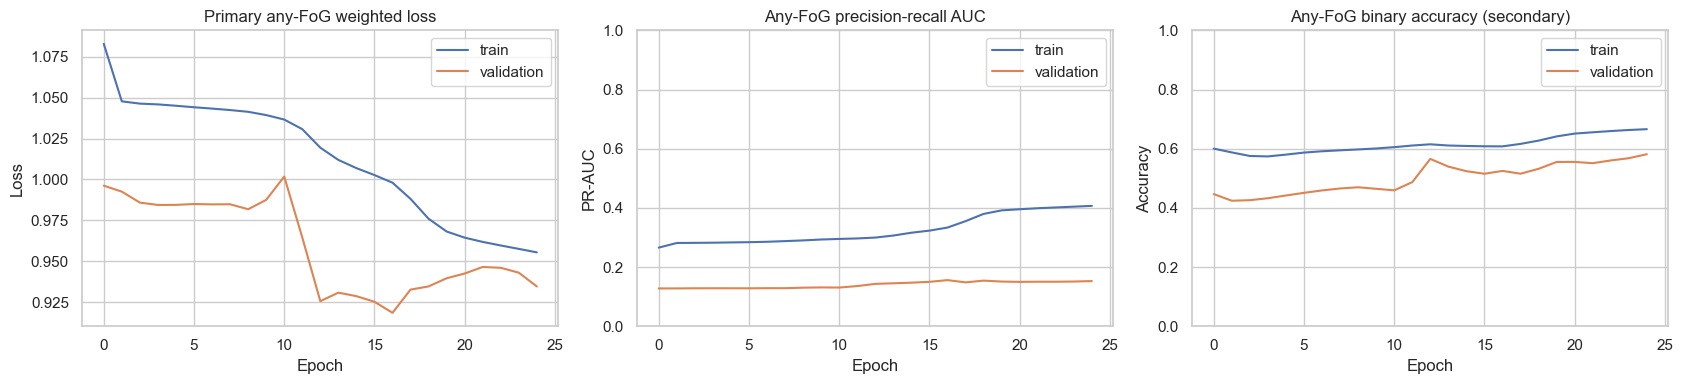

In [9]:
if history is not None:
    history_frame = pd.DataFrame(history.history)
    display(history_frame)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(history_frame["fog_loss"], label="train")
    axes[0].plot(history_frame["val_fog_loss"], label="validation")
    axes[0].set_title("Primary any-FoG weighted loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_frame["fog_pr_auc"], label="train")
    axes[1].plot(history_frame["val_fog_pr_auc"], label="validation")
    axes[1].set_title("Any-FoG precision-recall AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(history_frame["fog_binary_accuracy"], label="train")
    axes[2].plot(
        history_frame["val_fog_binary_accuracy"], label="validation"
    )
    axes[2].set_title("Any-FoG binary accuracy (secondary)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Learning curves are unavailable because training is disabled.")

## Final test — evaluate once

Validation-selected any-FoG threshold: 0.05


,threshold,episode_precision,episode_recall,episode_f1,false_alarms_per_minute,mean_duration_iou,true_episodes,predicted_episodes,matched_episodes
0,0.05,0.029046,0.091304,0.044071,5.322638,0.407065,230,723,21
1,0.10,0.014542,0.204348,0.027152,24.149004,0.423519,230,3232,47
2,0.15,0.020083,0.400000,0.038246,34.036068,0.471644,230,4581,92
3,0.20,0.019906,0.513043,0.038324,44.052028,0.485772,230,5928,118
4,0.25,0.016159,0.560870,0.031414,59.549850,0.470382,230,7983,129
5,0.30,0.013776,0.595652,0.026929,74.365283,0.475309,230,9945,137
6,0.35,0.010137,0.556522,0.019911,94.768727,0.452913,230,12627,128
7,0.40,0.006813,0.478261,0.013435,121.579049,0.465283,230,16145,110
8,0.45,0.005139,0.395652,0.010145,133.581521,0.449576,230,17709,91
9,0.50,0.004332,0.321739,0.008549,128.948855,0.450579,230,17081,74


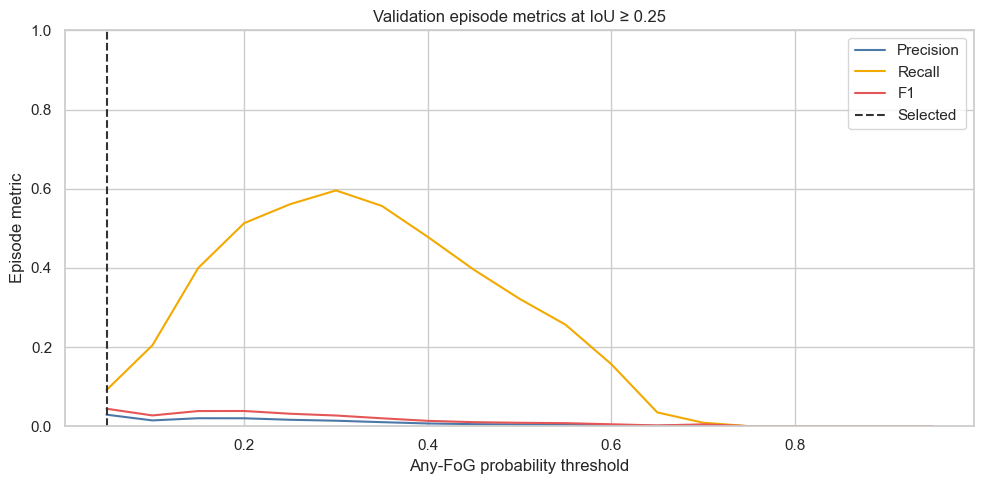

,fog_loss,any_fog_prevalence,average_precision,balanced_accuracy,precision,recall,f1
split,,,,,,,
train,0.994711,0.182268,0.352131,0.529644,0.191559,0.999509,0.321501
validation,0.918669,0.115239,0.155969,0.503699,0.115999,0.999901,0.207881
test,1.014174,0.175232,0.239975,0.560649,0.194713,0.999939,0.325955


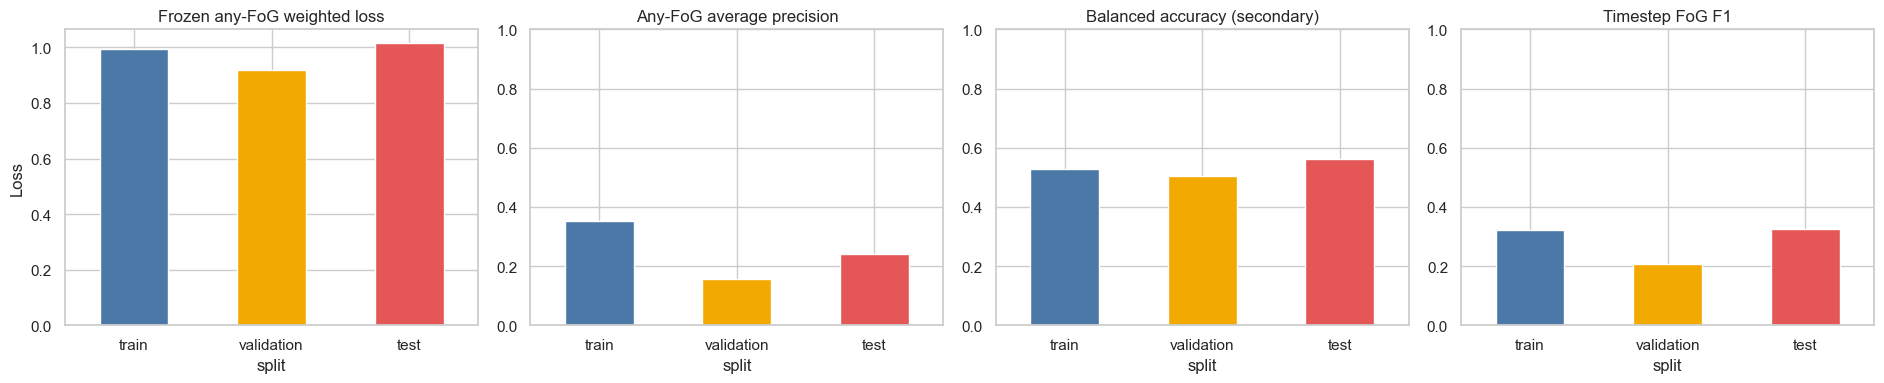

,held_out_test
threshold_selected_on_validation,0.050000
positive_prevalence,0.175232
average_precision,0.239975
balanced_accuracy,0.560649
precision,0.194713
recall,0.999939
f1,0.325955


,held_out_test
true_episodes,278.000000
predicted_episodes,1003.000000
matched_episodes,23.000000
false_positive_episodes,980.000000
missed_episodes,255.000000
episode_precision,0.022931
episode_recall,0.082734
episode_f1,0.035909
false_alarms_per_minute,7.020468
mean_onset_delay_seconds,-14.023913


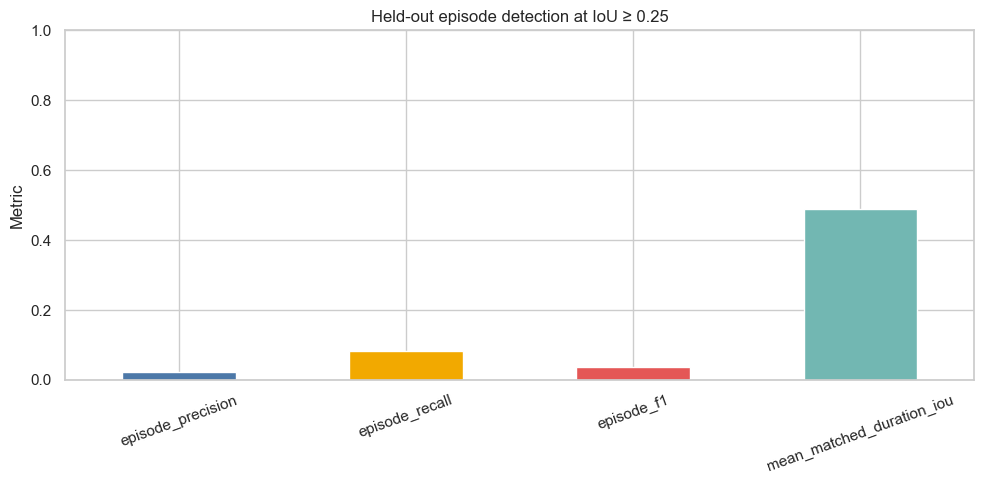

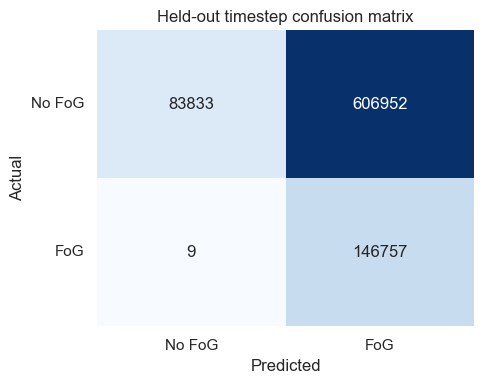

,threshold,positive_prevalence,average_precision,precision,recall,f1
target,,,,,,
StartHesitation,0.007888,0.000221,0.000281,0.000316,0.935135,0.000631
Turn,0.307786,0.170754,0.302766,0.220250,0.795679,0.345001
Walking,0.748309,0.004258,0.006397,0.007562,0.121144,0.014236


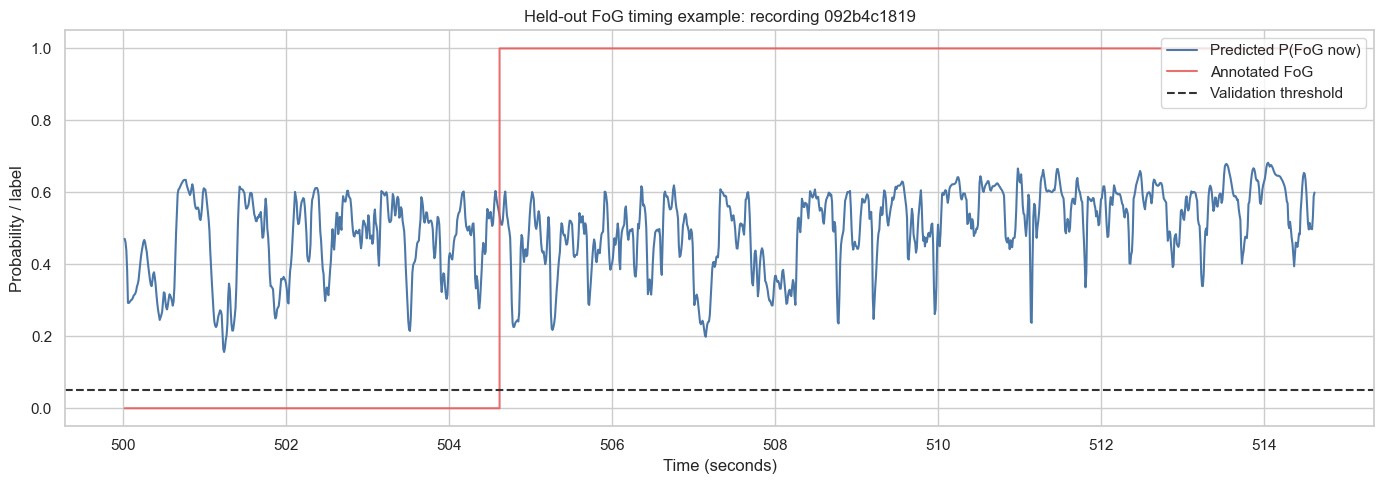

In [10]:
if model is not None:
    from sklearn.metrics import (
        average_precision_score,
        balanced_accuracy_score,
        confusion_matrix,
        f1_score,
        precision_recall_curve,
        precision_score,
        recall_score,
    )

    def unpack_model_outputs(outputs):
        if isinstance(outputs, dict):
            return outputs["fog"], outputs["event_type"]
        output_by_name = dict(zip(model.output_names, outputs))
        return output_by_name["fog"], output_by_name["event_type"]

    validation_outputs = model.predict(
        prepared.X_validation,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    validation_fog_probabilities, validation_type_probabilities = unpack_model_outputs(
        validation_outputs
    )
    decision_threshold, threshold_search = select_episode_threshold(
        prepared.alignment_splits.validation,
        prepared.y_any_fog_validation,
        validation_fog_probabilities,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        thresholds=np.linspace(0.05, 0.95, 19),
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    print(f"Validation-selected any-FoG threshold: {decision_threshold:.2f}")
    display(threshold_search)

    plt.figure(figsize=(10, 5))
    for metric, colour in (
        ("episode_precision", "#4c78a8"),
        ("episode_recall", "#f2a900"),
        ("episode_f1", "#e45756"),
    ):
        plt.plot(
            threshold_search["threshold"],
            threshold_search[metric],
            label=metric.replace("episode_", "").title(),
            color=colour,
        )
    plt.axvline(decision_threshold, color="#333333", linestyle="--", label="Selected")
    plt.title(f"Validation episode metrics at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    plt.xlabel("Any-FoG probability threshold")
    plt.ylabel("Episode metric")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Freeze the model and validation-selected threshold before examining test.
    split_evaluations = []
    split_probabilities = {}
    for split_name, X_values, y_fog_values, y_type_values in (
        ("train", prepared.X_train, prepared.y_any_fog_train, prepared.y_train),
        (
            "validation",
            prepared.X_validation,
            prepared.y_any_fog_validation,
            prepared.y_validation,
        ),
        ("test", prepared.X_test, prepared.y_any_fog_test, prepared.y_test),
    ):
        evaluation = model.evaluate(
            X_values,
            {"fog": y_fog_values, "event_type": y_type_values},
            batch_size=BATCH_SIZE,
            return_dict=True,
            verbose=0,
        )
        outputs = model.predict(X_values, batch_size=BATCH_SIZE, verbose=0)
        fog_probabilities, type_probabilities = unpack_model_outputs(outputs)
        split_probabilities[split_name] = (fog_probabilities, type_probabilities)
        fog_true = y_fog_values.reshape(-1)
        fog_score = fog_probabilities.reshape(-1)
        fog_predicted = (fog_score >= decision_threshold).astype(np.int8)
        split_evaluations.append(
            {
                "split": split_name,
                "fog_loss": evaluation["fog_loss"],
                "any_fog_prevalence": fog_true.mean(),
                "average_precision": average_precision_score(fog_true, fog_score),
                "balanced_accuracy": balanced_accuracy_score(
                    fog_true, fog_predicted
                ),
                "precision": precision_score(
                    fog_true, fog_predicted, zero_division=0
                ),
                "recall": recall_score(fog_true, fog_predicted, zero_division=0),
                "f1": f1_score(fog_true, fog_predicted, zero_division=0),
            }
        )

    split_evaluation_frame = pd.DataFrame(split_evaluations).set_index("split")
    display(split_evaluation_frame)
    split_colours = ["#4c78a8", "#f2a900", "#e45756"]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4))
    split_evaluation_frame["fog_loss"].plot.bar(ax=axes[0], color=split_colours)
    axes[0].set_title("Frozen any-FoG weighted loss")
    axes[0].set_ylabel("Loss")
    axes[0].tick_params(axis="x", rotation=0)
    for axis, metric, title in (
        (axes[1], "average_precision", "Any-FoG average precision"),
        (axes[2], "balanced_accuracy", "Balanced accuracy (secondary)"),
        (axes[3], "f1", "Timestep FoG F1"),
    ):
        split_evaluation_frame[metric].plot.bar(ax=axis, color=split_colours)
        axis.set_title(title)
        axis.set_ylim(0, 1)
        axis.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    test_fog_probabilities, test_type_probabilities = split_probabilities["test"]
    test_fog_true = prepared.y_any_fog_test.reshape(-1)
    test_fog_score = test_fog_probabilities.reshape(-1)
    test_fog_predictions = (test_fog_score >= decision_threshold).astype(np.int8)
    point_metrics = pd.Series(
        {
            "threshold_selected_on_validation": decision_threshold,
            "positive_prevalence": test_fog_true.mean(),
            "average_precision": average_precision_score(
                test_fog_true, test_fog_score
            ),
            "balanced_accuracy": balanced_accuracy_score(
                test_fog_true, test_fog_predictions
            ),
            "precision": precision_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "recall": recall_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "f1": f1_score(test_fog_true, test_fog_predictions, zero_division=0),
        },
        name="held_out_test",
    )
    display(point_metrics.to_frame())

    episode_evaluation = evaluate_episode_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    episode_metrics = pd.Series(
        {
            "true_episodes": episode_evaluation.true_count,
            "predicted_episodes": episode_evaluation.predicted_count,
            "matched_episodes": episode_evaluation.true_positive_count,
            "false_positive_episodes": episode_evaluation.false_positive_count,
            "missed_episodes": episode_evaluation.false_negative_count,
            "episode_precision": episode_evaluation.precision,
            "episode_recall": episode_evaluation.recall,
            "episode_f1": episode_evaluation.f1,
            "false_alarms_per_minute": episode_evaluation.false_alarms_per_minute,
            "mean_onset_delay_seconds": episode_evaluation.mean_onset_delay_seconds,
            "median_onset_delay_seconds": episode_evaluation.median_onset_delay_seconds,
            "mean_absolute_onset_error_seconds": episode_evaluation.mean_absolute_onset_error_seconds,
            "mean_matched_duration_iou": episode_evaluation.mean_duration_iou,
            "evaluated_minutes": episode_evaluation.evaluation_minutes,
        },
        name="held_out_test",
    )
    display(episode_metrics.to_frame())

    episode_bar_values = episode_metrics.loc[
        [
            "episode_precision",
            "episode_recall",
            "episode_f1",
            "mean_matched_duration_iou",
        ]
    ]
    ax = episode_bar_values.plot.bar(
        figsize=(10, 5),
        color=["#4c78a8", "#f2a900", "#e45756", "#72b7b2"],
    )
    ax.set_title(f"Held-out episode detection at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    matrix = confusion_matrix(
        test_fog_true,
        test_fog_predictions,
        labels=[0, 1],
    )
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Held-out timestep confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["No FoG", "FoG"])
    plt.yticks([0.5, 1.5], ["No FoG", "FoG"], rotation=0)
    plt.tight_layout()
    plt.show()

    # Event type remains an auxiliary description, not the primary objective.
    type_thresholds = []
    type_metric_rows = []
    for target_index, target in enumerate(TARGET_COLUMNS):
        validation_precision, validation_recall, candidate_thresholds = precision_recall_curve(
            prepared.y_validation[:, target_index],
            validation_type_probabilities[:, target_index],
        )
        validation_f1 = (
            2
            * validation_precision[:-1]
            * validation_recall[:-1]
            / np.maximum(
                validation_precision[:-1] + validation_recall[:-1], 1e-12
            )
        )
        type_threshold = float(
            candidate_thresholds[int(np.nanargmax(validation_f1))]
        )
        type_thresholds.append(type_threshold)
        y_true = prepared.y_test[:, target_index]
        y_score = test_type_probabilities[:, target_index]
        y_pred = (y_score >= type_threshold).astype(np.int8)
        type_metric_rows.append(
            {
                "target": target,
                "threshold": type_threshold,
                "positive_prevalence": y_true.mean(),
                "average_precision": average_precision_score(y_true, y_score),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    display(pd.DataFrame(type_metric_rows).set_index("target"))

    # Fixed-rule example: first held-out recording containing an annotated FoG row.
    aligned_test = align_binary_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
    )
    recording_totals = aligned_test.groupby(
        "RecordingId", observed=True
    )["AnyFoGTrue"].sum()
    positive_recordings = sorted(
        recording_totals.loc[recording_totals > 0].index,
        key=str,
    )
    if positive_recordings:
        example_recording_id = positive_recordings[0]
        example = aligned_test.loc[
            aligned_test["RecordingId"] == example_recording_id
        ].sort_values("TimeSeconds", kind="stable")
        first_positive_time = float(
            example.loc[example["AnyFoGTrue"] == 1, "TimeSeconds"].iloc[0]
        )
        example_window = example.loc[
            example["TimeSeconds"].between(
                max(0.0, first_positive_time - 5.0),
                first_positive_time + 10.0,
            )
        ]

        fig, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            example_window["TimeSeconds"],
            example_window["AnyFoGScore"],
            color="#4c78a8",
            label="Predicted P(FoG now)",
        )
        axis.step(
            example_window["TimeSeconds"],
            example_window["AnyFoGTrue"],
            where="post",
            color="#e45756",
            alpha=0.85,
            label="Annotated FoG",
        )
        axis.axhline(
            decision_threshold,
            color="#333333",
            linestyle="--",
            label="Validation threshold",
        )
        axis.set_title(
            f"Held-out FoG timing example: recording {example_recording_id}"
        )
        axis.set_xlabel("Time (seconds)")
        axis.set_ylabel("Probability / label")
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
    else:
        print("No positive held-out recording was available for a timing example.")
else:
    print("No final test evaluation was run because training is disabled.")

## Takeaways

The model now measures performance on unseen subjects, and no LSTM
window can mix recordings, cross unobserved gaps, or contain shuffled
timesteps. Its primary output is P(FoG now) at each window endpoint.